## Outlier Detection

The objective of this analysis is to identify potential outliers in the cleaned HR Employee 
Attrition dataset.

An outlier is a value that is unusually high or low compared with the majority of the 
observations.

The Interquartile Range (IQR) method will be used to identify potential outliers in relevant 
numerical variables. The identified values will then be reviewed to determine whether they 
represent data errors or legitimate employee characteristics.

In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Load the dataset
df = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
#Identify numerical columns
df.select_dtypes(include=np.number).columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')

## Selecting Columns for Outlier Detection

Outlier detection only makes sense for continuous numerical variables. Some numeric columns in this 
dataset are actually IDs, constants, or categorical/rating variables and should be excluded:

- **`EmployeeNumber`** — unique ID, not a measurable quantity
- **`EmployeeCount`** — constant value (no variance) across all records
- **`StandardHours`** — constant value (no variance) across all records
- **`Rating and categorical-coded variables`** – Variables such as JobLevel, Education, JobSatisfaction, PerformanceRating, and WorkLifeBalance represent categories or rating scales rather than continuous measurements. Therefore, they were not included in the IQR-based outlier analysis.

Therefore, only genuine continuous variables are used for outlier detection:

outlier_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]


In [5]:
#Outlier Columns
outlier_cols = [
    'Age',
    'DailyRate',
    'DistanceFromHome',
    'HourlyRate',
    'MonthlyIncome',
    'MonthlyRate',
    'NumCompaniesWorked',
    'PercentSalaryHike',
    'TotalWorkingYears',
    'TrainingTimesLastYear',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]


In [6]:
df[outlier_cols].head()

,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,94,5993,19479,8,11,8,0,6,4,0,5
1,49,279,8,61,5130,24907,1,23,10,3,10,7,1,7
2,37,1373,2,92,2090,2396,6,15,7,3,0,0,0,0
3,33,1392,3,56,2909,23159,1,11,8,3,8,7,3,0
4,27,591,2,40,3468,16632,9,12,6,3,2,2,2,2


In [7]:
#Statistical distribution of the variables
df[outlier_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0
MonthlyRate,1470.0,14313.103401,7117.786044,2094.0,8047.0,14235.5,20461.50,26999.0
NumCompaniesWorked,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.00,9.0
PercentSalaryHike,1470.0,15.209524,3.659938,11.0,12.0,14.0,18.00,25.0
TotalWorkingYears,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.00,40.0
TrainingTimesLastYear,1470.0,2.799320,1.289271,0.0,2.0,3.0,3.00,6.0


## IQR Method

The Interquartile Range (IQR) method is used to identify potential outliers.

The IQR represents the middle 50% of the data.

The calculation is:

- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 - Q1

The lower and upper boundaries are calculated as:

- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Values below the lower bound or above the upper bound are identified as potential outliers.

In [13]:
#Detect outliers using IQR (Interquartile Range)
outlier_results = []

for column in outlier_cols:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    outlier_results.append({
        'Column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Number of Potential Outliers': len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_results)

outlier_summary

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Potential Outliers
0,Age,30.0,43.00,13.00,10.500,62.500,0
1,DailyRate,465.0,1157.00,692.00,-573.000,2195.000,0
2,DistanceFromHome,2.0,14.00,12.00,-16.000,32.000,0
3,HourlyRate,48.0,83.75,35.75,-5.625,137.375,0
4,MonthlyIncome,2911.0,8379.00,5468.00,-5291.000,16581.000,114
5,MonthlyRate,8047.0,20461.50,12414.50,-10574.750,39083.250,0
6,NumCompaniesWorked,1.0,4.00,3.00,-3.500,8.500,52
7,PercentSalaryHike,12.0,18.00,6.00,3.000,27.000,0
8,TotalWorkingYears,6.0,15.00,9.00,-7.500,28.500,63
9,TrainingTimesLastYear,2.0,3.00,1.00,0.500,4.500,238


In [ ]:
# Outlier Percentage
outlier_summary['Outlier Percentage'] = (
    outlier_summary['Number of Potential Outliers'] / len(df) * 100
).round(2)

outlier_summary

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Potential Outliers,Outlier Percentage
0,Age,30.0,43.00,13.00,10.500,62.500,0,0.00
1,DailyRate,465.0,1157.00,692.00,-573.000,2195.000,0,0.00
2,DistanceFromHome,2.0,14.00,12.00,-16.000,32.000,0,0.00
3,HourlyRate,48.0,83.75,35.75,-5.625,137.375,0,0.00
4,MonthlyIncome,2911.0,8379.00,5468.00,-5291.000,16581.000,114,7.76
5,MonthlyRate,8047.0,20461.50,12414.50,-10574.750,39083.250,0,0.00
6,NumCompaniesWorked,1.0,4.00,3.00,-3.500,8.500,52,3.54
7,PercentSalaryHike,12.0,18.00,6.00,3.000,27.000,0,0.00
8,TotalWorkingYears,6.0,15.00,9.00,-7.500,28.500,63,4.29
9,TrainingTimesLastYear,2.0,3.00,1.00,0.500,4.500,238,16.19


In [ ]:
# Columns Have the Most Outliers
outlier_summary.sort_values(
    'Number of Potential Outliers',
    ascending=False
)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Potential Outliers,Outlier Percentage
9,TrainingTimesLastYear,2.0,3.00,1.00,0.500,4.500,238,16.19
4,MonthlyIncome,2911.0,8379.00,5468.00,-5291.000,16581.000,114,7.76
12,YearsSinceLastPromotion,0.0,3.00,3.00,-4.500,7.500,107,7.28
10,YearsAtCompany,3.0,9.00,6.00,-6.000,18.000,104,7.07
8,TotalWorkingYears,6.0,15.00,9.00,-7.500,28.500,63,4.29
6,NumCompaniesWorked,1.0,4.00,3.00,-3.500,8.500,52,3.54
11,YearsInCurrentRole,2.0,7.00,5.00,-5.500,14.500,21,1.43
13,YearsWithCurrManager,2.0,7.00,5.00,-5.500,14.500,14,0.95
5,MonthlyRate,8047.0,20461.50,12414.50,-10574.750,39083.250,0,0.00
1,DailyRate,465.0,1157.00,692.00,-573.000,2195.000,0,0.00


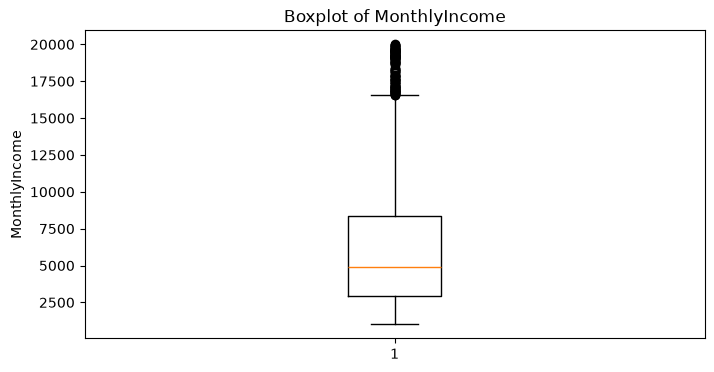

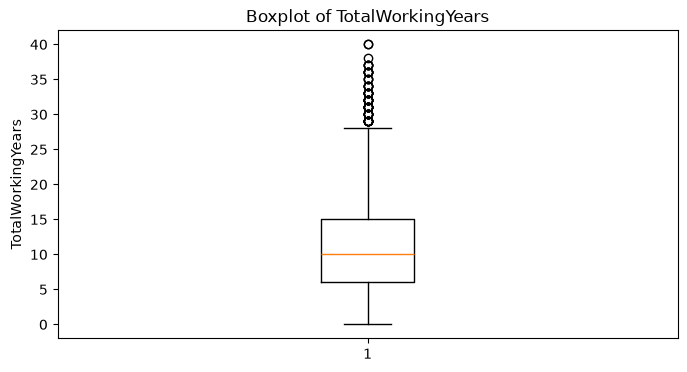

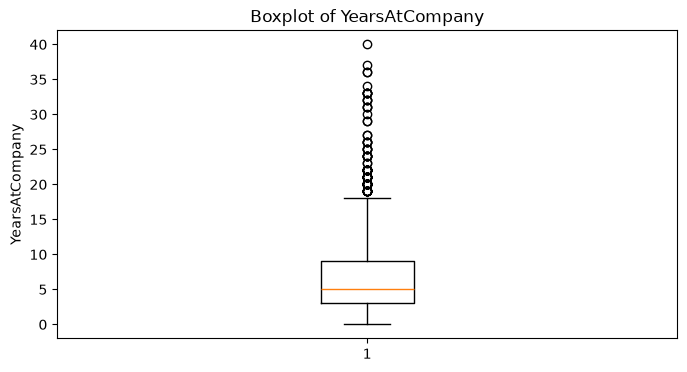

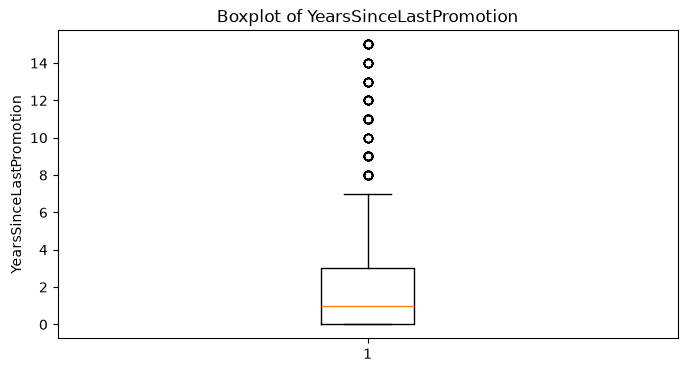

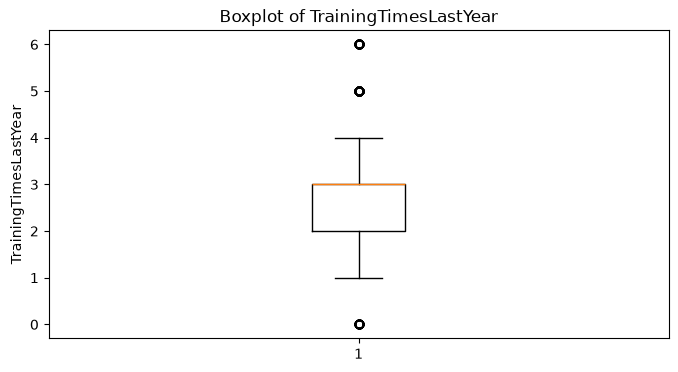

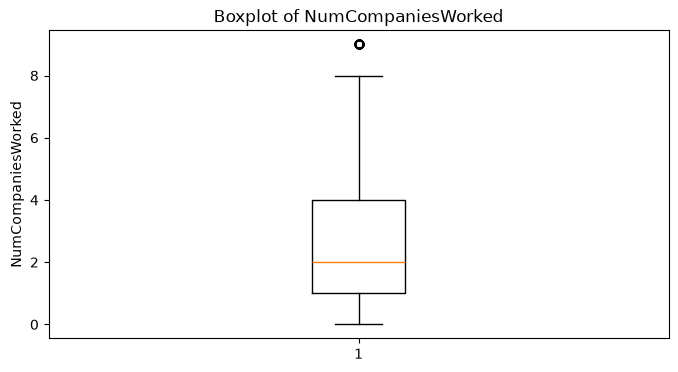

In [18]:
#Visualize the outliers
columns_to_plot = [
    'MonthlyIncome',
    'TotalWorkingYears',
    'YearsAtCompany',
    'YearsSinceLastPromotion',
    'TrainingTimesLastYear',
    'NumCompaniesWorked'
]

for column in columns_to_plot:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[column])
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)
    plt.show()

In [23]:
Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -5291.0
Upper Bound: 16581.0


In [ ]:
# Investigate the Potential Outliers
# Let's say `MonthlyIncome` has potential outliers.
monthly_income_outliers = df[
    (df['MonthlyIncome'] < lower_bound) |
    (df['MonthlyIncome'] > upper_bound)
]

monthly_income_outliers[
    ['Age', 'JobLevel', 'JobRole', 'MonthlyIncome', 'TotalWorkingYears']
].sort_values('MonthlyIncome')

,Age,JobLevel,JobRole,MonthlyIncome,TotalWorkingYears
466,41,4,Manager,16595,22
1043,53,4,Research Director,16598,35
1080,46,4,Manager,16606,23
489,43,4,Research Director,16627,21
379,55,4,Manager,16659,30
...,...,...,...,...,...
568,55,5,Manager,19859,24
165,50,5,Manager,19926,21
851,56,5,Manager,19943,28
746,41,5,Research Director,19973,21


## Outlier Treatment

The potential outliers identified using the IQR method were reviewed based on the business context of the HR Employee Attrition dataset.

The analysis showed that many of the unusual values represent legitimate employee characteristics, such as higher income, greater work experience,longer tenure, or a higher number of training sessions.

Since these values are possible and do not appear to be data-entry errors, they were not removed from the dataset.

Retaining these observations helps preserve meaningful information about the employee population and prevents the unnecessary loss of data.

## Conclusion

The IQR method was used to identify potential outliers in relevant numerical variables in the HR Employee Attrition dataset.

Potential outliers were identified primarily in variables related to employee income, work experience, company tenure, promotions, and training.

The identified values were reviewed in the context of the dataset. Most of the potential outliers appeared to represent legitimate employee characteristics rather than data-entry errors.

Therefore, the potential outliers were retained rather than removed. This approach preserves the original information in the dataset and avoids removing valid employee observations that may be important for further employee attrition analysis.